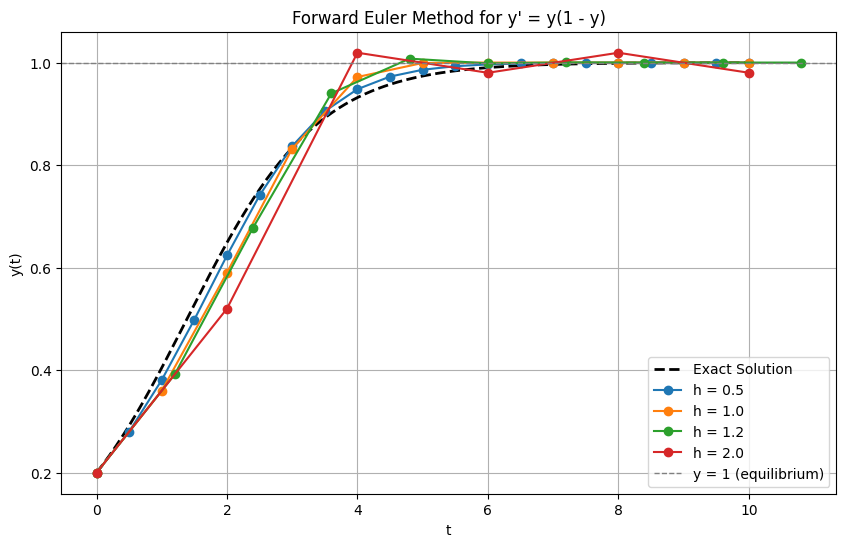

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Forward Euler method for y' = y(1 - y)
def forward_euler_logistic(y0, h, t_end=10):
    t = np.arange(0, t_end + h, h)
    y = np.zeros(len(t))
    y[0] = y0
    for n in range(len(t) - 1):
        y[n + 1] = y[n] + h * y[n] * (1 - y[n])
    return t, y

# Exact solution (for comparison)
def exact_solution(t, y0):
    return y0 * np.exp(t) / (1 + y0 * (np.exp(t) - 1))

# Initial condition
y0 = 0.2

# Step sizes to test
hs = [0.5, 1.0, 1.2, 2.0]

# Exact curve
t_exact = np.linspace(0, 10, 300)
y_exact = exact_solution(t_exact, y0)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(t_exact, y_exact, 'k--', linewidth=2, label='Exact Solution')

for h in hs:
    t, y = forward_euler_logistic(y0, h)
    plt.plot(t, y, 'o-', label=f'h = {h}')

plt.axhline(1, color='gray', linestyle='--', linewidth=1, label='y = 1 (equilibrium)')
plt.title("Forward Euler Method for y' = y(1 - y)")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.grid(True)
plt.show()


| Step size (h) | Behavior                               | Qualitatively correct? |
| ------------- | -------------------------------------- | ---------------------- |
| (h = 0.5)     | Smooth monotone growth to 1            | ✅ Yes                  |
| (h = 1.0)     | Reaches 1 but may just touch the limit | ✅ Borderline stable    |
| (h = 1.2)     | Overshoots above 1        | ❌ No                   |
| (h = 2.0)     | Strong oscillations or divergence      | ❌ No                   |
